In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

In [2]:
path = r'..\data\processed\cleaned_diabetes.csv'
dataset = pd.read_csv(path)
dataset.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1


In [3]:
x = dataset.drop('Outcome', axis = 1)
y = dataset['Outcome']

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler = StandardScaler()

In [8]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [9]:
y_train.value_counts()

Outcome
0    400
1    214
Name: count, dtype: int64

In [10]:
from imblearn.over_sampling import SMOTE

In [11]:
smote = SMOTE()

In [12]:
x_train_res, y_train_res = smote.fit_resample(x_train_scaled, y_train)

## LOGISTIC REGRESSION

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
model = LogisticRegression()

In [15]:
model.fit(x_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_pred = model.predict(x_test_scaled)

In [17]:
model.score(x_test_scaled, y_test)

0.7272727272727273

In [18]:
import joblib

In [19]:
joblib.dump(model, '../models/logistic_regression_model.pkl')

['../models/logistic_regression_model.pkl']

### Model Evaluation - LR

In [20]:
from sklearn.metrics import precision_score, accuracy_score, f1_score, recall_score, confusion_matrix, classification_report

In [23]:
cm_lr = confusion_matrix(y_test, y_pred)
cm_lr

array([[74, 26],
       [16, 38]])

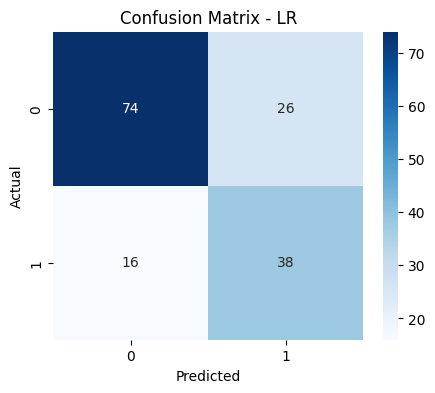

In [69]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LR")
plt.savefig("../reports/figures/confusion_matrix_lr.png")
plt.show()

In [26]:
accuracy_lr = accuracy_score(y_test, y_pred)
accuracy_lr

0.7272727272727273

In [27]:
precision_lr = precision_score(y_test, y_pred)
precision_lr

0.59375

In [28]:
recall_lr = recall_score(y_test, y_pred)
recall_lr

0.7037037037037037

In [29]:
f1_lr = f1_score(y_test, y_pred)
f1_lr

0.6440677966101694

In [30]:
report_lr = classification_report(y_test, y_pred)
print(report_lr)

              precision    recall  f1-score   support

           0       0.82      0.74      0.78       100
           1       0.59      0.70      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



In [75]:
with open("../reports/lr_model_metrics.txt", "w") as f:
    f.write(f"Accuracy: {accuracy_lr}\n")
    f.write(f"Precision: {precision_lr}\n")
    f.write(f"Recall: {recall_lr}\n")
    f.write(f"F1 Score: {f1_lr}\n")

In [77]:
with open("../reports/lr_classification_report.txt", "w") as f:
    f.write(report_lr)

In [34]:
print("MODEL PERFORMANCE SUMMARY")
print("--------------------------")
print("Accuracy:", accuracy_lr)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1 Score:", f1_lr)

MODEL PERFORMANCE SUMMARY
--------------------------
Accuracy: 0.7272727272727273
Precision: 0.59375
Recall: 0.7037037037037037
F1 Score: 0.6440677966101694


In [35]:
# TEST
import numpy as np
input_data = np.array([[5, 120, 72, 30, 0, 32.0, 0.5, 33]])
model.predict(input_data)

array([1])

## NAIVE BAYES

In [58]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

In [60]:
gnb.fit(x_train_res, y_train_res)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [61]:
y_pred_gnb = gnb.predict(x_test_scaled)

In [62]:
gnb.score(x_test_scaled, y_test)

0.6948051948051948

In [63]:
joblib.dump(model, '../models/naive_bayes_model.pkl')

['../models/naive_bayes_model.pkl']

### Model Evaluation - NB

In [65]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
cm_gnb

array([[72, 28],
       [19, 35]])

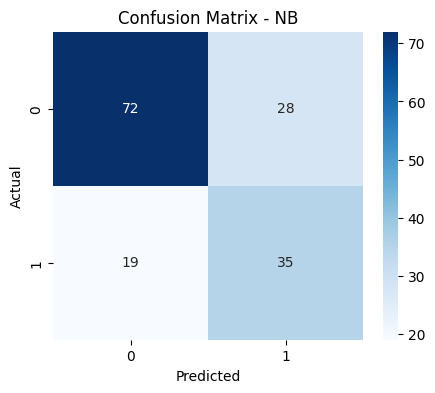

In [68]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_gnb, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - NB")
plt.savefig("../reports/figures/confusion_matrix_nb.png")
plt.show()

In [70]:
accuracy_nb = accuracy_score(y_test, y_pred_gnb)
accuracy_nb

0.6948051948051948

In [71]:
precision_nb = precision_score(y_test, y_pred_gnb)
precision_nb

0.5555555555555556

In [72]:
recall_nb = recall_score(y_test, y_pred_gnb)
recall_nb

0.6481481481481481

In [73]:
f1_nb = f1_score(y_test, y_pred_gnb)
f1_nb

0.5982905982905983

In [74]:
report_nb = classification_report(y_test, y_pred_gnb)
print(report_nb)

              precision    recall  f1-score   support

           0       0.79      0.72      0.75       100
           1       0.56      0.65      0.60        54

    accuracy                           0.69       154
   macro avg       0.67      0.68      0.68       154
weighted avg       0.71      0.69      0.70       154



In [76]:
with open("../reports/nb_model_metrics.txt", "w") as f:
    f.write(f"Accuracy: {accuracy_nb}\n")
    f.write(f"Precision: {precision_nb}\n")
    f.write(f"Recall: {recall_nb}\n")
    f.write(f"F1 Score: {f1_nb}\n")

In [78]:
with open("../reports/nb_classification_report.txt", "w") as f:
    f.write(report_nb)

In [80]:
print("MODEL PERFORMANCE SUMMARY")
print("--------------------------")
print("Accuracy:", accuracy_nb)
print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1 Score:", f1_nb)

MODEL PERFORMANCE SUMMARY
--------------------------
Accuracy: 0.6948051948051948
Precision: 0.5555555555555556
Recall: 0.6481481481481481
F1 Score: 0.5982905982905983


In [81]:
# TEST
input_data = np.array([[5, 120, 72, 30, 0, 32.0, 0.5, 33]])
gnb.predict(input_data)

array([1])

## MODELS COMPARISON

In [83]:
comparison = {
    "Model": ["Logistic Regression", "Naive Bayes"],
    
    "Accuracy": [
        accuracy_lr,
        accuracy_nb
    ],
    
    "Precision": [
        precision_lr,
        precision_nb
    ],
    
    "Recall": [
        recall_lr,
        recall_nb
    ],
    
    "F1 Score": [
        f1_lr,
        f1_nb
    ]
}

In [85]:
comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.727273,0.593750,0.703704,0.644068
1,Naive Bayes,0.694805,0.555556,0.648148,0.598291


In [86]:
comparison_df.to_csv("../reports/model_comparison.csv", index=False)

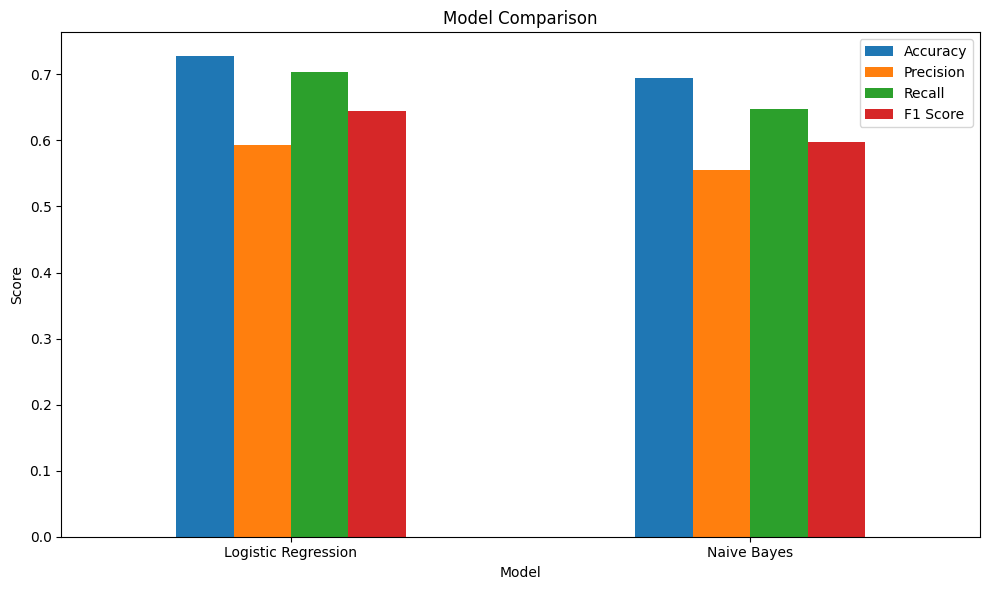

In [96]:
comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/model_comparison.png")
plt.show()

In [94]:
comparison_df.set_index("Model")

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.727273,0.593750,0.703704,0.644068
Naive Bayes,0.694805,0.555556,0.648148,0.598291
